In [ ]:
!pip install jaxopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 4.6 MB/s eta 0:00:00


In [ ]:
import jax
import jax.numpy as jnp
import optax
import jaxopt
from jax import random

import matplotlib.pyplot as plt
import math
import numpy as np
import time

In [ ]:
activation_function = jax.nn.tanh # defines tanh as activation function

In [ ]:
PI = jnp.pi
# Função teórica exata
def u_exact(x, y, z):
    return jnp.sin(PI * x) * jnp.sin(PI * y) * jnp.sin(PI * z)

In [ ]:
# hyperparameters
width = [3] + 5*[20] + [1]
lr = 1e-3
b1 = 0.9
b2 = 0.999
eps = 1e-08
eps_root = 0.0
epochs = 20000

In [ ]:
initializer = jax.nn.initializers.glorot_normal() # Glorot initialization
key    = jax.random.split(jax.random.PRNGKey(136), len(width) - 1)
params = list()

for key, lin, lout in zip(key, width[:-1], width[1:]):
  W = initializer(key, (lin, lout), jnp.float32)
  B = initializer(key, (1, lout)  , dtype=jnp.float32)
  params.append({'W': W, 'B': B})

In [ ]:
# Define function for forward pass
@jax.jit #Just in time compilation
def forward(xyz, params):
  """xy: shape (N, 3)"""
  x = xyz
  *hidden, output = params
  for layer in hidden:
    x = activation_function(x @ layer['W'] + layer['B'])

  return x @ output['W'] + output['B']

In [ ]:
def u_net(x, y, z, params):
    """Retorna u(x, y) da rede neural"""
    xyz = jnp.array([[x, y, z]])
    return forward(xyz, params)[0, 0]

In [ ]:
def laplacian_u(x, y, z, params):
    """Calcula laplaciano de u"""
    u_xx = jax.grad(jax.grad(lambda x_: u_net(x_, y, z, params), 0), 0)(x) # du2_dx2
    u_yy = jax.grad(jax.grad(lambda y_: u_net(x, y_, z, params), 0), 0)(y) # du2_dy2
    u_zz = jax.grad(jax.grad(lambda z_: u_net(x, y, z_, params), 0), 0)(z) # du2_dz2

    return u_xx + u_yy + u_zz


In [ ]:
def pde_rhs(x, y, z):
    """RHS da formulação fraca """
    return -3 * PI**2 * jnp.sin(PI * x) * jnp.sin(PI * y) * jnp.sin(PI * z)


In [ ]:
def loss_function_interior(params, xyz_interior):
    """Loss da PDE no interior"""
    def residual(xyz):
        x, y, z = xyz[0], xyz[1], xyz[2]
        lap_u = laplacian_u(x, y, z, params)
        rhs = pde_rhs(x, y, z)
        return (lap_u - rhs)**2

    residuals = jax.vmap(residual)(xyz_interior)
    return jnp.mean(residuals)

def loss_bc_x0(params, xyz):
    """Dirichlet em x=0: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], pt[2], params)**2
    return jnp.mean(jax.vmap(residual)(xyz))

def loss_bc_x1(params, xyz):
    """Dirichlet em x=1: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], pt[2], params)**2
    return jnp.mean(jax.vmap(residual)(xyz))

def loss_bc_y0(params, xyz):
    """Dirichlet em y=0: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], pt[2], params)**2
    return jnp.mean(jax.vmap(residual)(xyz))

def loss_bc_y1(params, xyz):
    """Dirichlet em y=1: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], pt[2], params)**2
    return jnp.mean(jax.vmap(residual)(xyz))

def loss_bc_z0(params, xyz):
    """Dirichlet em z=0: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], pt[2], params)**2
    return jnp.mean(jax.vmap(residual)(xyz))

def loss_bc_z1(params, xyz):
    """Dirichlet em z=1: u = 0"""
    def residual(pt):
        return u_net(pt[0], pt[1], pt[2], params)**2
    return jnp.mean(jax.vmap(residual)(xyz))

@jax.jit
def loss_function(params, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1):
    """Loss total = Loss PDE + Loss Contornos Explícitos (6 faces)"""
    loss_pde = loss_function_interior(params, xyz_interior)
    l_x0 = loss_bc_x0(params, xyz_x0)
    l_x1 = loss_bc_x1(params, xyz_x1)
    l_y0 = loss_bc_y0(params, xyz_y0)
    l_y1 = loss_bc_y1(params, xyz_y1)
    l_z0 = loss_bc_z0(params, xyz_z0)
    l_z1 = loss_bc_z1(params, xyz_z1)

    return loss_pde + l_x0 + l_x1 + l_y0 + l_y1 + l_z0 + l_z1

In [ ]:
# ===== GERAÇÃO DE DADOS =====
key_f = jax.random.PRNGKey(42)
key_g = jax.random.PRNGKey(43)

N_f = 2000  # Pontos de colocação interior
N_g = 100   # Pontos na fronteira

# Pontos de colocação interior
xyz_interior = jax.random.uniform(key_f, shape=(N_f, 3), minval=0.0, maxval=1.0)

# Extraindo e definindo cada face explicitamente
xyz_x0 = jnp.column_stack([
    jnp.zeros(N_g),
    jax.random.uniform(jax.random.fold_in(key_g, 0), shape=(N_g,)),
    jax.random.uniform(jax.random.fold_in(key_g, 1), shape=(N_g,))
])

xyz_x1 = jnp.column_stack([
    jnp.ones(N_g),
    jax.random.uniform(jax.random.fold_in(key_g, 2), shape=(N_g,)),
    jax.random.uniform(jax.random.fold_in(key_g, 3), shape=(N_g,))
])

xyz_y0 = jnp.column_stack([
    jax.random.uniform(jax.random.fold_in(key_g, 4), shape=(N_g,)),
    jnp.zeros(N_g),
    jax.random.uniform(jax.random.fold_in(key_g, 5), shape=(N_g,))
])

xyz_y1 = jnp.column_stack([
    jax.random.uniform(jax.random.fold_in(key_g, 6), shape=(N_g,)),
    jnp.ones(N_g),
    jax.random.uniform(jax.random.fold_in(key_g, 7), shape=(N_g,))
])

xyz_z0 = jnp.column_stack([
    jax.random.uniform(jax.random.fold_in(key_g, 8), shape=(N_g,)),
    jax.random.uniform(jax.random.fold_in(key_g, 9), shape=(N_g,)),
    jnp.zeros(N_g)
])

xyz_z1 = jnp.column_stack([
    jax.random.uniform(jax.random.fold_in(key_g, 10), shape=(N_g,)),
    jax.random.uniform(jax.random.fold_in(key_g, 11), shape=(N_g,)),
    jnp.ones(N_g)
])

In [ ]:
#Initilize optimizer
optimizer = optax.adam(lr, b1, b2, eps, eps_root)
opt_state = optimizer.init(params)

In [ ]:
#Define the gradient function
grad_loss = jax.jit(jax.grad(loss_function, 0))

In [ ]:
#Define update function
@jax.jit
def update(opt_state, params, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1):
    grads = grad_loss(params, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return opt_state, params

In [ ]:
# ===== TREINAMENTO COM ADAM =====
print("="*70)
print("TREINAMENTO COM ADAM")
print("="*70)
print("Iniciando treinamento...")
t0 = time.time()
for e in range(epochs):
    opt_state, params = update(opt_state, params, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1)
    if e % 2000 == 0:
        loss = loss_function(params, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1)
        elapsed = time.time() - t0
        print(f"{elapsed:.4f}s | Epoch {e:<6}: Loss {loss:.12f}")

elapsed_adam = time.time() - t0
loss_adam = loss_function(params, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1)
print(f"{elapsed_adam:.4f}s | Epoch {epochs-1:<6}: Loss {loss_adam:.12f}")
print("Treinamento com Adam concluído!\n")


# ===== REFINAMENTO COM L-BFGS (JAXOpt) =====
print("="*70)
print("REFINAMENTO COM L-BFGS (JAXOpt)")
print("="*70)
print("Iniciando refinamento...")

# Flatten params para o vetor 1D
params_flat, unflatten_fn = jax.flatten_util.ravel_pytree(params)

@jax.jit
def objective_lbfgs(params_flat):
    params_unflat = unflatten_fn(params_flat)
    return loss_function(params_unflat, xyz_interior, xyz_x0, xyz_x1, xyz_y0, xyz_y1, xyz_z0, xyz_z1)

t0_lbfgs = time.time()

# Configurar o otimizador L-BFGS
lbfgs = jaxopt.LBFGS(
    fun=objective_lbfgs,
    maxiter=20000,
    history_size=50,
    tol=1e-8
)

# Executar a otimização
params_final_flat, state = lbfgs.run(params_flat)

elapsed_lbfgs = time.time() - t0_lbfgs

# Extrair e remontar os parâmetros otimizados
params = unflatten_fn(params_final_flat)

# Avaliação pós L-BFGS
loss_lbfgs = state.error
num_iters = state.iter_num

print(f"L-BFGS concluído em {elapsed_lbfgs:.3f}s")
print(f"Loss após L-BFGS: {loss_lbfgs:.12f}")
print(f"Número de iterações L-BFGS: {num_iters}")
print()

# ===== RESUMO DO TREINAMENTO =====
print("="*70)
print("RESUMO DO TREINAMENTO")
print("="*70)
print(f"Adam:")
print(f"  Tempo: {elapsed_adam:.3f}s")
print(f"  Epochs: {epochs}")
print(f"  Loss final: {loss_adam:.12f}")
print(f"\nL-BFGS:")
print(f"  Tempo: {elapsed_lbfgs:.3f}s")
print(f"  Loss final: {loss_lbfgs:.12f}")
print(f"\nMelhoria com L-BFGS:")
print(f"  Redução de loss: {(loss_adam - loss_lbfgs) / loss_adam * 100:.2f}%")
print(f"  Tempo total: {elapsed_adam + elapsed_lbfgs:.3f}s")
print("="*70 + "\n")

TREINAMENTO COM ADAM
Iniciando treinamento...
6.5614s | Epoch 0     : Loss 115.827079772949
9.7978s | Epoch 2000  : Loss 0.061508208513
12.9410s | Epoch 4000  : Loss 0.023056607693
16.0841s | Epoch 6000  : Loss 0.012131789699
19.2276s | Epoch 8000  : Loss 0.009809914045
22.3694s | Epoch 10000 : Loss 0.005261484534
25.5060s | Epoch 12000 : Loss 0.005789730698
28.6430s | Epoch 14000 : Loss 0.014478930272
31.7802s | Epoch 16000 : Loss 0.003199446015
34.9173s | Epoch 18000 : Loss 0.022895626724
38.0524s | Epoch 19999 : Loss 0.002680844394
Treinamento com Adam concluído!

REFINAMENTO COM L-BFGS (JAXOpt)
Iniciando refinamento...
L-BFGS concluído em 469.398s
Loss após L-BFGS: 0.002667099936
Número de iterações L-BFGS: 20000

RESUMO DO TREINAMENTO
Adam:
  Tempo: 38.052s
  Epochs: 20000
  Loss final: 0.002680844394

L-BFGS:
  Tempo: 469.398s
  Loss final: 0.002667099936

Melhoria com L-BFGS:
  Redução de loss: 0.51%
  Tempo total: 507.450s



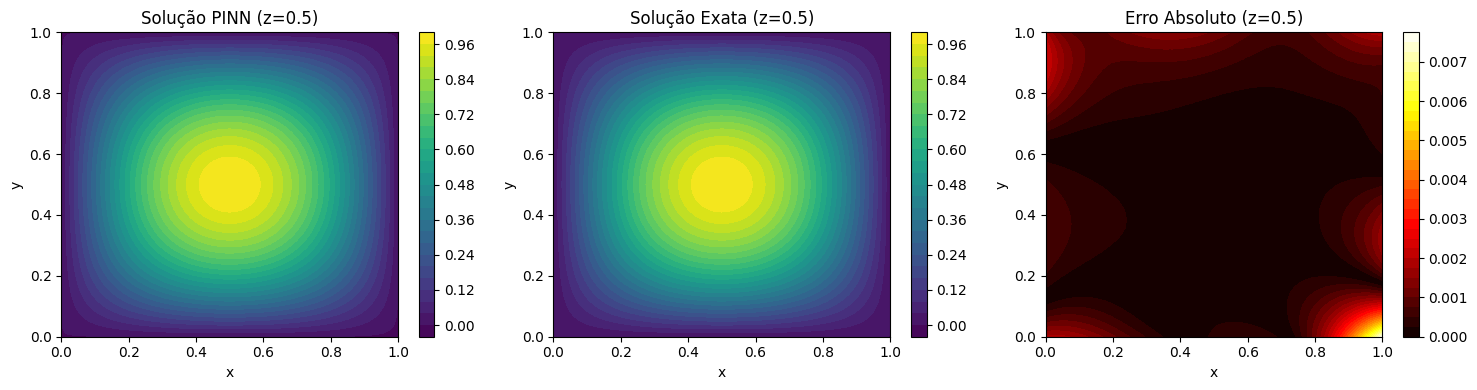

Erro máximo (absoluto): 7.65694678e-03
Erro médio (absoluto): 4.06211679e-04
Erro relativo (L2): 1.38369459e-03
Erro relativo (percentual): 0.1384%


In [ ]:
n_eval = 150
x_eval = jnp.linspace(0, 1, n_eval)
y_eval = jnp.linspace(0, 1, n_eval)
z_slice = 0.5 # Fatia em z = 0.5

X_mesh, Y_mesh = jnp.meshgrid(x_eval, y_eval)

# Solucao da rede neural
x_flat = X_mesh.ravel()
y_flat = Y_mesh.ravel()
z_flat = jnp.full_like(x_flat, z_slice)

t_eval_start = time.time()
xyz_points = jnp.stack([x_flat, y_flat, z_flat], axis=-1)
u_nn_flat = forward(xyz_points, params)
u_nn = u_nn_flat.reshape(X_mesh.shape)
time_evaluation = time.time() - t_eval_start

# Solução exata na fatia
u_exact_grid = u_exact(X_mesh, Y_mesh, z_slice)

# Erro absoluto
error = jnp.abs(u_nn - u_exact_grid)

# ===== PLOTS =====
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].contourf(X_mesh, Y_mesh, u_nn, levels=30, cmap='viridis')
axes[0].set_title(f'Solução PINN (z={z_slice})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].contourf(X_mesh, Y_mesh, u_exact_grid, levels=30, cmap='viridis')
axes[1].set_title(f'Solução Exata (z={z_slice})')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].contourf(X_mesh, Y_mesh, error, levels=30, cmap='hot')
axes[2].set_title(f'Erro Absoluto (z={z_slice})')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

# ===== MÉTRICAS DE ERRO NA FATIA =====
erro_maximo = jnp.max(error)
erro_medio = jnp.mean(error)

# Erro relativo L2 na fatia
norma_exata = jnp.sqrt(jnp.sum(u_exact_grid**2))
norma_erro = jnp.sqrt(jnp.sum(error**2))
erro_relativo = norma_erro / norma_exata


print(f"Erro máximo (absoluto): {erro_maximo:.8e}")
print(f"Erro médio (absoluto): {erro_medio:.8e}")
print(f"Erro relativo (L2): {erro_relativo:.8e}")
print(f"Erro relativo (percentual): {erro_relativo * 100:.4f}%")

In [ ]:
# ===== CONTAR PARÂMETROS =====
params_flat_final, _ = jax.flatten_util.ravel_pytree(params)
num_params = len(params_flat_final)

# ===== SALVAR RESULTADOS =====
results = {
    'architecture': width,
    'error_relativo': float(erro_relativo),
    'time_training': float(elapsed_adam),
    'time_training_w_lbfgs': float(elapsed_adam + elapsed_lbfgs),
    'time_evaluation': float(time_evaluation),
    'num_params': int(num_params),
    'u_nn': np.asarray(u_nn),
    'u_exact': np.asarray(u_exact_grid),
    'error': np.asarray(error),
    'X_mesh': np.asarray(X_mesh),
    'Y_mesh': np.asarray(Y_mesh),
    'z_slice': z_slice,
    'network_weights': np.asarray(params_flat_final) # Salva os pesos otimizados (opcional, mas muito útil)
}

filename = f'pinn_lbfgs_3d_{width}.npz'
np.savez_compressed(filename, **results)
print(f"\nDados salvos com sucesso no arquivo '{filename}'!")


Dados salvos com sucesso no arquivo 'pinn_lbfgs_3d_[3, 20, 20, 20, 20, 20, 1].npz'!
